# Vehicle Detection + Counter on Fine Tuning YOLOv26

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("roboflow dataset")

# Import Dataset

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key=secret_value_0)
project = rf.workspace("belajar-yolo-dlwtw").project("deteksi-kendaraan-tgoh2-2o1e3")
version = project.version(2)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteksi-Kendaraan-2 in yolo26:: 100%|██████████| 5677/5677 [00:00<00:00, 7899.93it/s]


# Import Model

In [5]:
from ultralytics import YOLO

model = YOLO("yolo26m.pt")  # pass any model type

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Train Model

In [6]:
results = model.train(optimizer="AdamW", lr0=0.005, data=f"{dataset.location}/data.yaml", epochs=25)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Deteksi-Kendaraan-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, op

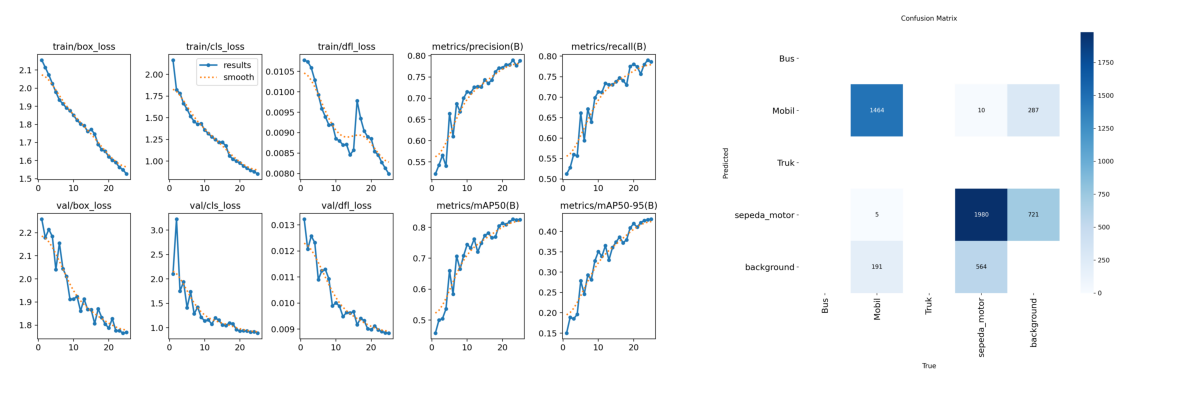

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# Load images
img1 = Image.open(r'runs\detect\train\results.png')
img2 = Image.open(r'runs\detect\train\confusion_matrix.png')

# Buat figure dengan 1 baris, 2 kolom, kolom pertama lebih lebar
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1.7, 1.3]})

# Plot gambar pertama (lebih besar)
axes[0].imshow(img1)
axes[0].axis("off")

# Plot gambar kedua (lebih kecil)
axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()


# Evaluation

In [ ]:
model = YOLO('runs/detect/train/weights/best.pt')

In [ ]:
metrics = model.val(data=f"{dataset.location}/data.yaml", split='test')

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26m summary (fused): 132 layers, 20,352,536 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1258.9±395.6 MB/s, size: 54.5 KB)
val: Scanning /kaggle/working/Deteksi-Kendaraan-2/test/labels... 118 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 1.2Kit/s 0.1s
val: New cache created: /kaggle/working/Deteksi-Kendaraan-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8it/s 4.3s0.5ss
                   all        118       2008      0.775      0.802      0.817      0.427
                 Mobil        111        864      0.828      0.855      0.881      0.523
          sepeda_motor        105       1144      0.722      0.749      0.753       0.33
Speed: 2.4ms preprocess, 25.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/va

In [9]:
# Menampilkan hasil metrik secara spesifik
print(f"mAP50-95: {metrics.box.map}") # Mean Average Precision di rentang IoU 0.50-0.95
print(f"mAP50: {metrics.box.map50}")  # Mean Average Precision di IoU 0.50
print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")

mAP50-95: 0.4267044222400921
mAP50: 0.816593988813945
Precision: [    0.82844     0.72196]
Recall: [    0.85532     0.74913]


# Inference

In [10]:
predicts = best.predict(source=f"{dataset.location}/test/images")


image 1/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/frame_1107_jpg.rf.2ed10fd5ff2a01ed4cc21a5afea43589.jpg: 480x640 2 Mobils, 5 sepeda_motors, 53.0ms
image 2/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/frame_1137_jpg.rf.a1dff7017ad6987d4ec26a4ea3cfb60f.jpg: 480x640 4 Mobils, 6 sepeda_motors, 29.7ms
image 3/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/frame_1232_jpg.rf.1d381260a8e41aa1030c327aa8571881.jpg: 480x640 3 Mobils, 5 sepeda_motors, 29.6ms
image 4/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/frame_1361_jpg.rf.609035bde21c24f3924351cb32afc77b.jpg: 480x640 8 sepeda_motors, 29.6ms
image 5/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/frame_174_jpg.rf.9ceb6ff722bc669e90f942afade5793d.jpg: 480x640 3 Mobils, 10 sepeda_motors, 29.6ms
image 6/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/frame_1755_jpg.rf.36e4403264a7cbd35a04560b306588ed.jpg: 480x640 2 Mobils, 5 sepeda_motors, 29.6ms
image 7/118 /kaggle/working/Deteksi-Kendaraan-2/test/images/f

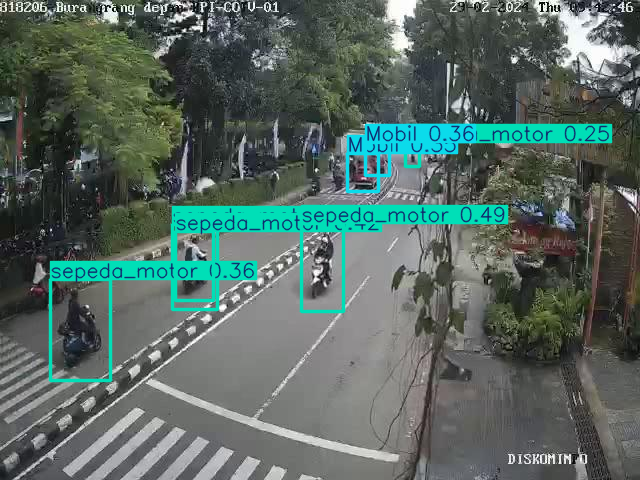

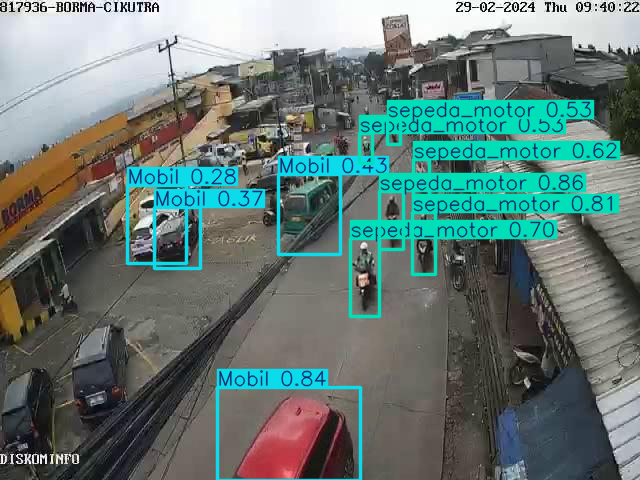

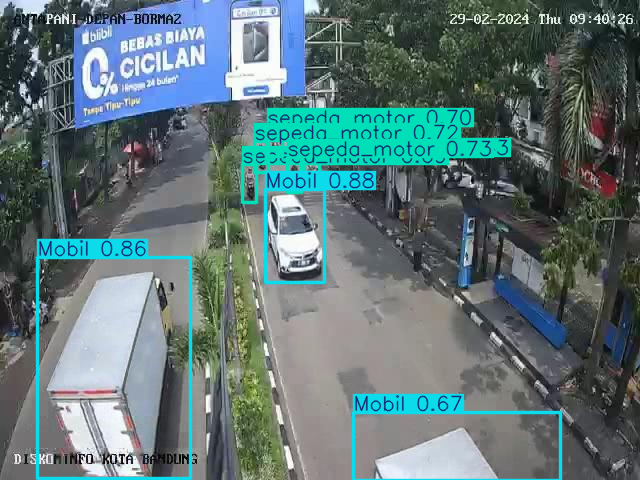

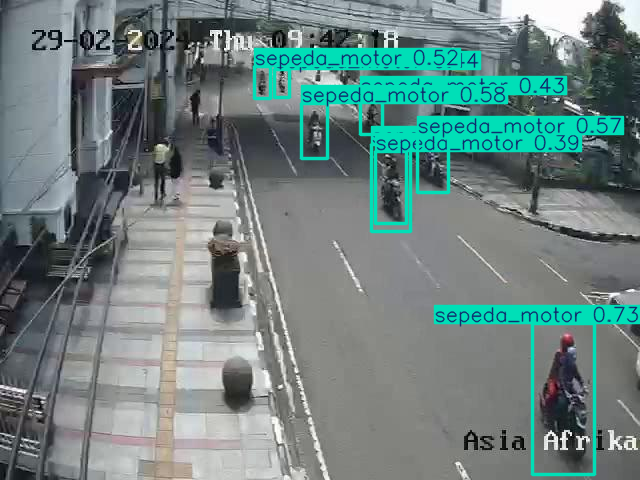

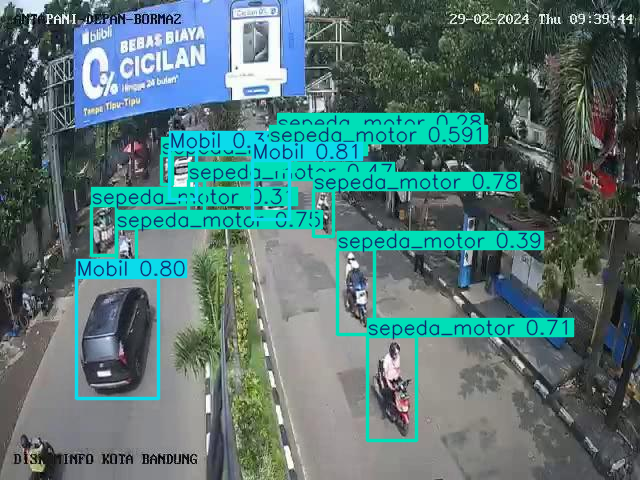

In [11]:
for predict in predicts[:5]:
    predict.show()

# Detection + Counter

Ditemukan 1 gambar untuk dites.

0: 384x640 7 Mobils, 13 sepeda_motors, 519.2ms
Speed: 4.2ms preprocess, 519.2ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)


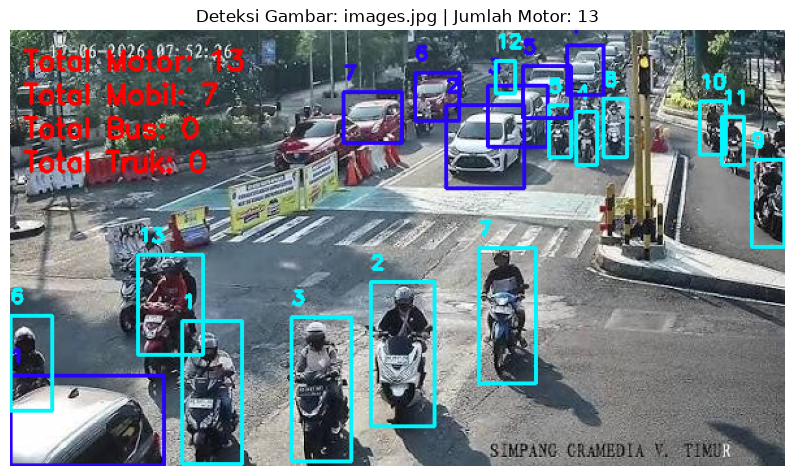

Selesai! Jumlah sepeda motor pada images.jpg: 13
Proses testing pada sampel gambar selesai.


In [ ]:
import cv2
import glob
import os

# 1. Muat model yang sudah Anda latih
model = YOLO('runs/detect/train/weights/best.pt')

# 2. Tentukan lokasi folder gambar testing Anda
# Pastikan Anda mengubah path ini ke folder yang berisi gambar-gambar testing Anda
path_gambar = 'images.jpg' 
image_paths = glob.glob(path_gambar)

# Batasi berapa banyak gambar yang ingin di-plot untuk pengecekan
max_images_to_plot = 3
images_plotted = 0

print(f"Ditemukan {len(image_paths)} gambar untuk dites.")

for img_path in image_paths:
    if images_plotted >= max_images_to_plot:
        break

    # Buka gambar
    frame = cv2.imread(img_path)
    if frame is None:
        print(f"Gagal memuat gambar: {img_path}")
        continue

    # Variabel untuk counter motor di gambar ini
    bus_count = 0
    sepeda_motor_count = 0
    mobil_count = 0
    truk_count = 0
    # 3. Jalankan YOLOv8 dengan mode PREDICT (bukan track)
    results = model.predict(frame)

    # Jika ada objek yang terdeteksi
    if len(results[0].boxes) > 0:
        boxes = results[0].boxes.xyxy.cpu()
        classes = results[0].boxes.cls.int().cpu().tolist()

        for box, cls in zip(boxes, classes):
            x1, y1, x2, y2 = map(int, box)

            # SESUAIKAN DI SINI: Berdasarkan model Anda, 'sepeda_motor' berada di indeks ke-3
            if cls == 0: # bus
                bus_count +=1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (177, 3, 252), 2) # ungu
                cv2.putText(frame, f"{bus_count}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (177, 3, 252), 2)                
            elif cls == 1: # mobil
                mobil_count +=1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (252, 3, 40), 2) # merah
                cv2.putText(frame, f"{mobil_count}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (252, 3, 40), 2)
            elif cls == 3:
                sepeda_motor_count += 1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (252, 244, 3), 2) # kuning
                cv2.putText(frame, f"{sepeda_motor_count}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (252, 244, 3), 2)            
            else:
                truk_count += 0
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2) # blue
                cv2.putText(frame, f"{truk_count}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    # 4. Tampilkan teks total di sudut layar gambar
    # Ambil ukuran frame
    height, width, _ = frame.shape  

    # Data teks yang ingin ditampilkan
    texts = [
        f"Total Motor: {sepeda_motor_count}",
        f"Total Mobil: {mobil_count}",
        f"Total Bus: {bus_count}",
        f"Total Truk: {truk_count}"
    ]

    # Ambil ukuran frame
    height, width, _ = frame.shape  

    # Data teks yang ingin ditampilkan
    texts = [
        f"Total Motor: {sepeda_motor_count}",
        f"Total Mobil: {mobil_count}",
        f"Total Bus: {bus_count}",
        f"Total Truk: {truk_count}"
    ]

    # Parameter font
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.7
    thickness = 2
    color = (0, 0, 255)

    # Loop untuk menampilkan tiap baris di kiri atas
    x = 10        # margin kiri
    y_offset = 30 # jarak dari atas
    for i, text in enumerate(texts):
        (text_w, text_h), _ = cv2.getTextSize(text, font, font_scale, thickness)
        y = y_offset + i * (text_h + 10)  # jarak antar baris
        cv2.putText(frame, text, (x, y), font, font_scale, color, thickness)


    # --- BAGIAN PLOT GAMBAR UNTUK PENGECEKAN NO-GUI ---
    # Konversi format warna OpenCV (BGR) ke Matplotlib (RGB)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    
    # Gunakan nama file gambar sebagai judul plot
    nama_file = os.path.basename(img_path)
    plt.title(f"Deteksi Gambar: {nama_file} | Jumlah Motor: {sepeda_motor_count}")
    plt.axis('off')
    plt.show()
    
    print(f"Selesai! Jumlah sepeda motor pada {nama_file}: {sepeda_motor_count}")
    images_plotted += 1

print("Proses testing pada sampel gambar selesai.")